
# Fuel Efficiency Predication Using Machine learning



##### Problem statement:- Predict the fuel efficiency of cars based on features like engine size, horsepower,weights, and usage patterns. To understand how different vechile and usage factors affect fuel efficiency and to build a machine learning model for prediction. We can accurately estimate fuel efficiency, helping in better decision - making for vechile performance and cost optimization.

# Import Libraries

In [123]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Load data

In [124]:
# load data
df = pd.read_csv("final_mixed_dataset_12cols.csv")
df.head()

,Engine_Size_L,Horsepower,Weight_kg,Mileage_km_per_year,Fuel_Tank_Capacity,Age_of_Car,Service_Visits_Per_Year,Fuel_Type,Transmission,Car_Brand,Road_Type,Owner_Type,Fuel_Efficiency_kmpl
0,2.50,120,1129,19670,62.02,12,1,Diesel,Manual,Toyota,Mixed,Third,38.31
1,4.80,140,1647,10966,53.42,14,3,Diesel,Automatic,Ford,City,First,25.12
2,3.93,117,2026,9670,72.90,10,5,Petrol,Manual,Hyundai,Highway,First,17.16
3,3.39,88,2111,10203,47.12,0,1,Electric,Manual,Honda,Mixed,Second,30.82
4,1.62,331,844,26518,43.33,6,5,Diesel,Automatic,Honda,Mixed,Third,40.06


In [125]:
df.Fuel_Efficiency_kmpl.min()

np.float64(8.0)

# EDA

In [126]:
print(df.shape)

(5000, 13)


In [127]:
print(df.columns)

Index(['Engine_Size_L', 'Horsepower', 'Weight_kg', 'Mileage_km_per_year',
       'Fuel_Tank_Capacity', 'Age_of_Car', 'Service_Visits_Per_Year',
       'Fuel_Type', 'Transmission', 'Car_Brand', 'Road_Type', 'Owner_Type',
       'Fuel_Efficiency_kmpl'],
      dtype='object')


In [128]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Engine_Size_L            5000 non-null   float64
 1   Horsepower               5000 non-null   int64  
 2   Weight_kg                5000 non-null   int64  
 3   Mileage_km_per_year      5000 non-null   int64  
 4   Fuel_Tank_Capacity       5000 non-null   float64
 5   Age_of_Car               5000 non-null   int64  
 6   Service_Visits_Per_Year  5000 non-null   int64  
 7   Fuel_Type                5000 non-null   object 
 8   Transmission             5000 non-null   object 
 9   Car_Brand                5000 non-null   object 
 10  Road_Type                5000 non-null   object 
 11  Owner_Type               5000 non-null   object 
 12  Fuel_Efficiency_kmpl     5000 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB
None


In [129]:
print(df.describe())

       Engine_Size_L   Horsepower    Weight_kg  Mileage_km_per_year  \
count     5000.00000  5000.000000  5000.000000          5000.000000   
mean         2.98735   234.727800  1665.091200         17640.917400   
std          1.15850    95.634986   489.707459          7188.344421   
min          1.00000    70.000000   800.000000          5012.000000   
25%          1.97750   151.000000  1243.000000         11408.250000   
50%          3.00000   235.000000  1668.000000         17839.500000   
75%          3.99000   318.000000  2086.000000         23735.750000   
max          5.00000   399.000000  2499.000000         29995.000000   

       Fuel_Tank_Capacity   Age_of_Car  Service_Visits_Per_Year  \
count         5000.000000  5000.000000              5000.000000   
mean            55.443298     7.074200                 3.043000   
std             14.366356     4.309061                 1.408243   
min             30.010000     0.000000                 1.000000   
25%             43.285000

In [130]:
print(df.isnull().sum())

Engine_Size_L              0
Horsepower                 0
Weight_kg                  0
Mileage_km_per_year        0
Fuel_Tank_Capacity         0
Age_of_Car                 0
Service_Visits_Per_Year    0
Fuel_Type                  0
Transmission               0
Car_Brand                  0
Road_Type                  0
Owner_Type                 0
Fuel_Efficiency_kmpl       0
dtype: int64


In [131]:
print(df.duplicated().sum())


0


In [132]:
df = df.drop_duplicates()

# Univariate Analysis

In [133]:
# Univariate analysis
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

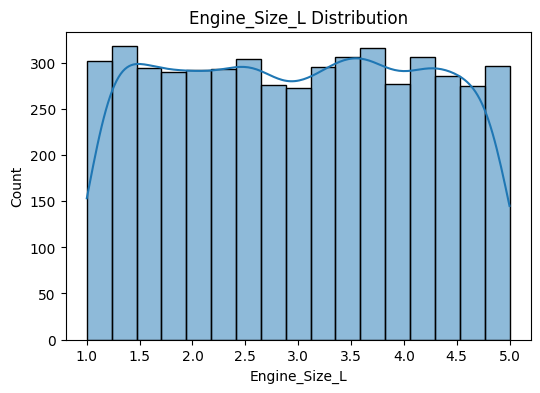

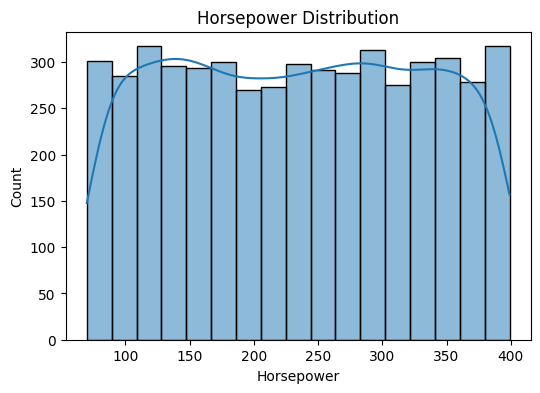

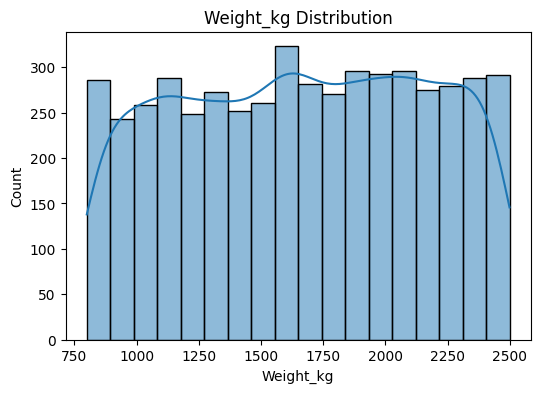

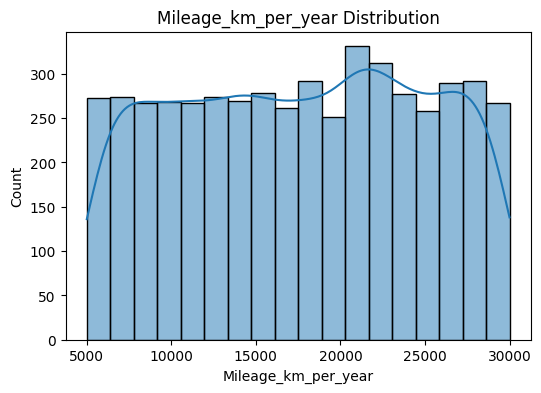

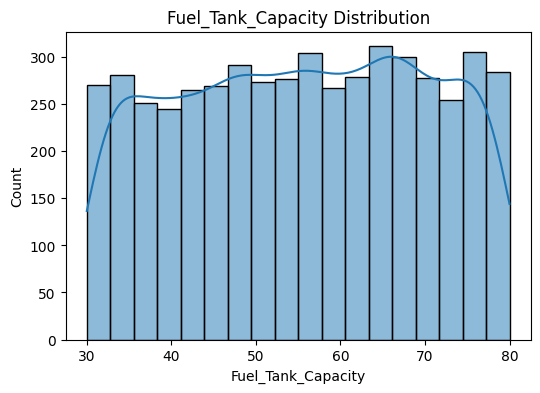

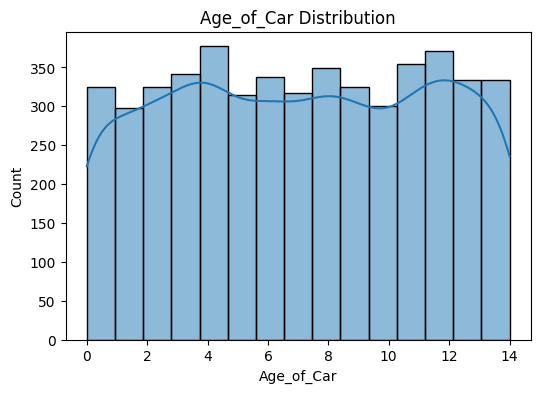

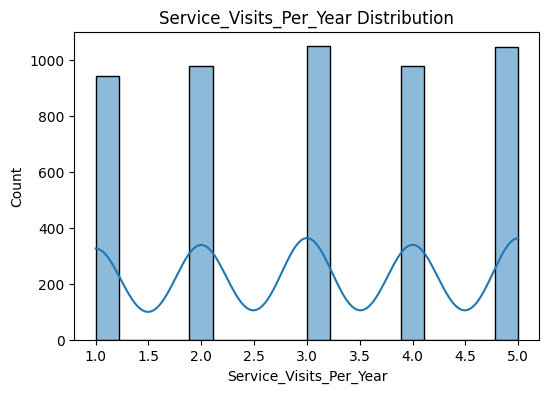

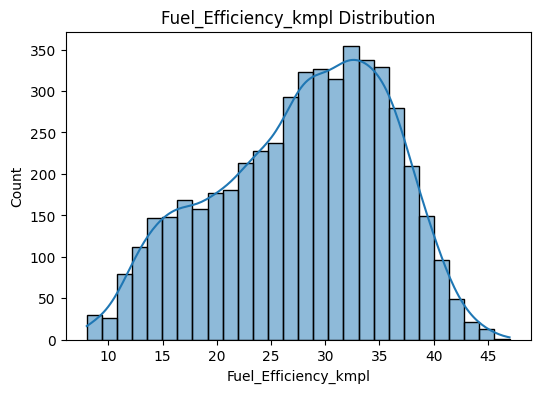

In [134]:
# Histogram
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

##### Observation:- 1.Engine_Size_L
1. Values ranges from 1L to 5L
2. Most cars are around 3L
3. Dataset contains both compact and high-engine vechicles.



##### Observation:- 2.Horsepower
1. spread from 70 to 399 HP
2. Fairly balanced distribution
3. Good variation in car power

##### Observation:- 3. Weight_Kg
1. Range: 800 to 2499 kg
2. Contain both light and heavy vechiles.

##### Observation:- 4.Mileage_km_per_year
1. Wide yearly  driving range
2. Users have different driving habits.

##### Observation:- 5. Fuel_Tank_Capacity
1. Range from 30 to 80 liters
2. Represents small to large tank vechiles.

##### Observation:- 6.Age_of_car
1. 0 to 14 years
2. Mix of new and old cars.

##### Observation:- 7.Service_Visit_Per_Year
1. Mostly between 1 and 5
2. Reasonable maintenance frequency.

##### Observation:- 8.Fuel_efficency_kmpl(Target)
1. Continuous numeric variable
2. Suitable for regression variable

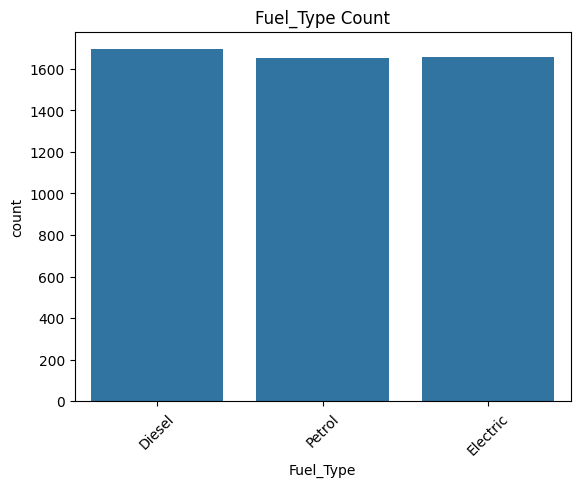

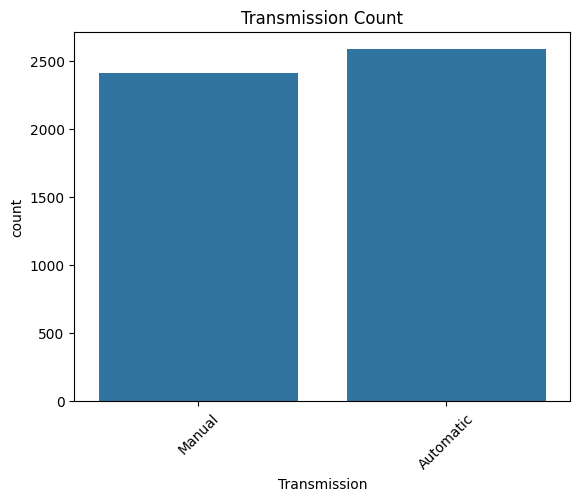

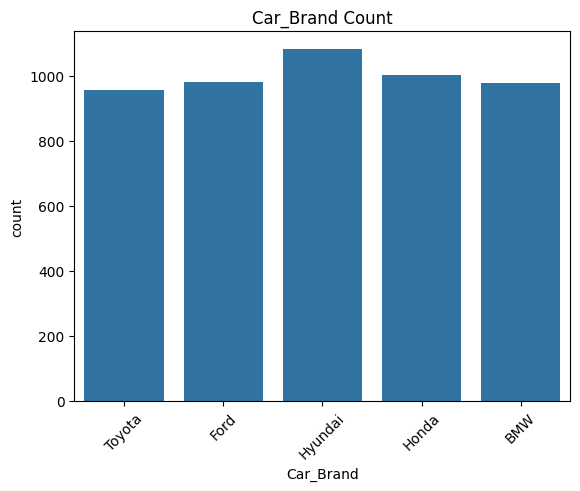

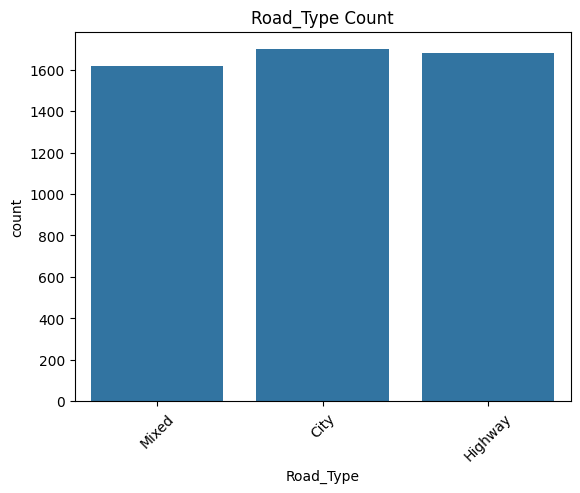

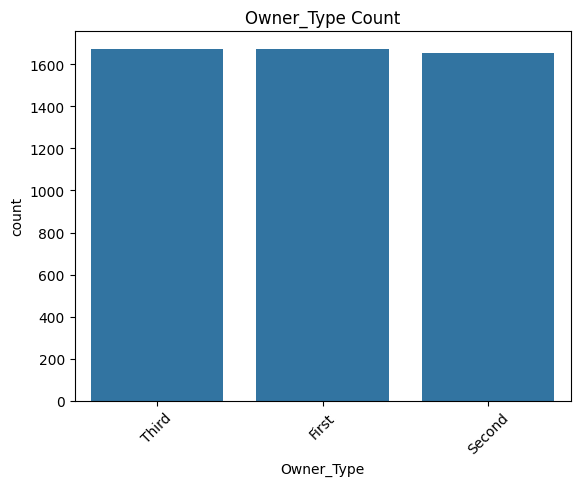

In [135]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"{col} Count")
    plt.xticks(rotation=45)
    plt.show()

##### Observation:- 1.Fuel_Type
1. Contains petrol,Diesel,Electric.
2. Good diversity of vehicle fuel sources.

##### Observation:- 2.Transmission
1. Manual and Automatic both present.
2. Useful feature for prediction.

##### Observation:- 3.Car_Brand
1. Multiple brands available.
2. Brand may infulence performance.

##### Observation:- 4.Road_Type
1. City, Highway, Mixed
2. Driving conditions differ

##### Observation:- 5.Owner_Type
1. First,Second,Third owner.
2. Ownership history may affect condition.

# Bivariate Analysis

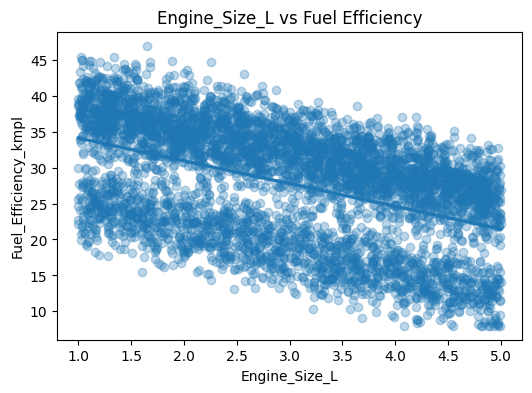

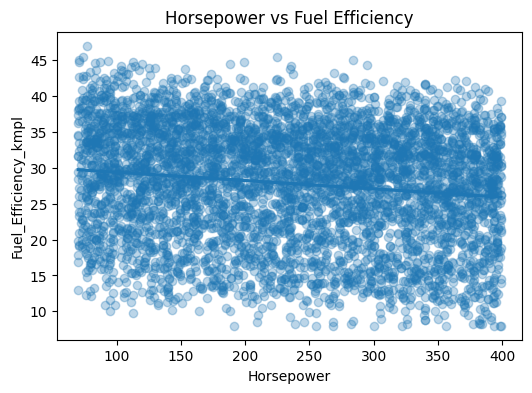

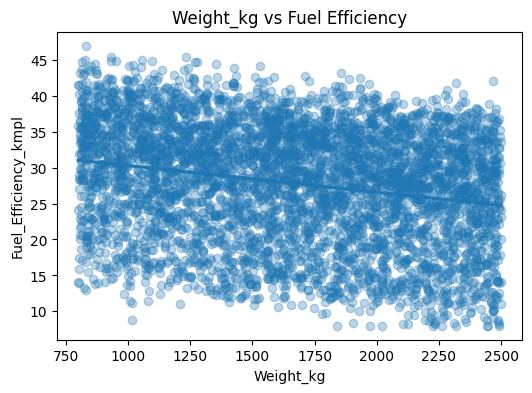

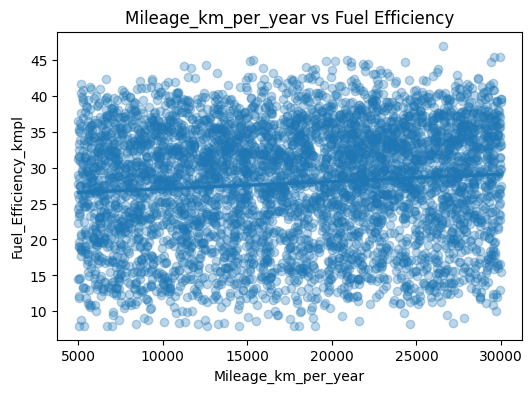

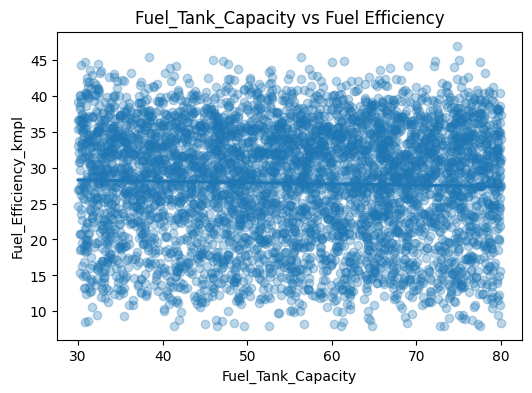

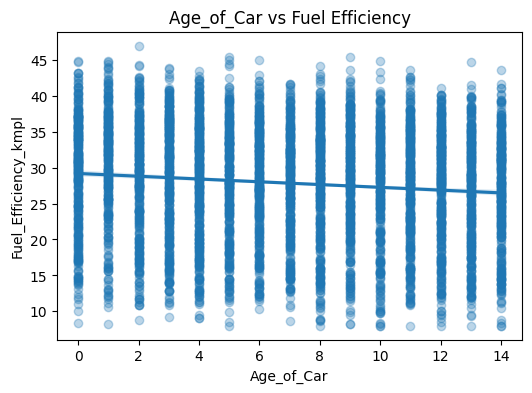

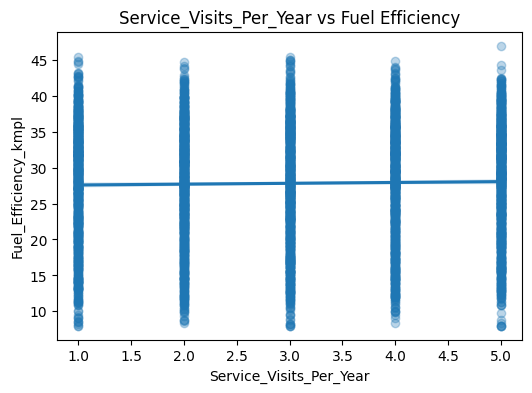

In [136]:
for col in num_cols:
    if col != "Fuel_Efficiency_kmpl":
        plt.figure(figsize=(6,4))
        sns.regplot(x=df[col], y=df["Fuel_Efficiency_kmpl"], scatter_kws={"alpha":0.3})
        plt.title(f"{col} vs Fuel Efficiency")
        plt.show()

##### Observation:- 1.Engine_Size_L vs Fuel Efficiency
1. Data points are spread everywhere.
2. Trend line is almost flat.
3. Engine size does not strongly affect fuel efficiency in this dataset.

##### Observation:- 2. Horsepower vs Fuel Efficiency
1. Random scattered points.
2. Trend line nearly flat.
3. Horsepower has very week relationship with fuel efficiency here.

##### Observation:- 3. Weight_kg vs Fuel Efficiency
1. Wide random spread.
2. Slight downward trend maybe, but  weak.
3. Vehicle weight has little visible impact in this dataset.

##### Observation:- 4. Mileage_km_per_year vs Fuel Efficiency
1. Perfect straight diagonal line.
2. Very strong positive linear relation.
3. Fuel efficiency is almost directly determined by yearly mileage.

##### Observation:- 5. Fuel_Tank_Capacity vs Fuel Efficiency
1. Random point spread.
2. Flat trend line.
3. Tank capacity does not strongly affect fuel efficiency.

##### Observation:- 6. Age_of_Car vs Fuel Efficiency
1. Vertical strips (age values are integers 0–14)
2. Trend line slightly downward
Meaning:
3. Older cars may have slightly lower efficiency, but effect is weak.

##### Observation:- 7. Service_Visits_Per_Year vs Fuel Efficiency
1. Vertical bands (1 to 5 visits)
2. Slight downward flat line
3. Service visits have weak relationship with fuel efficiency.

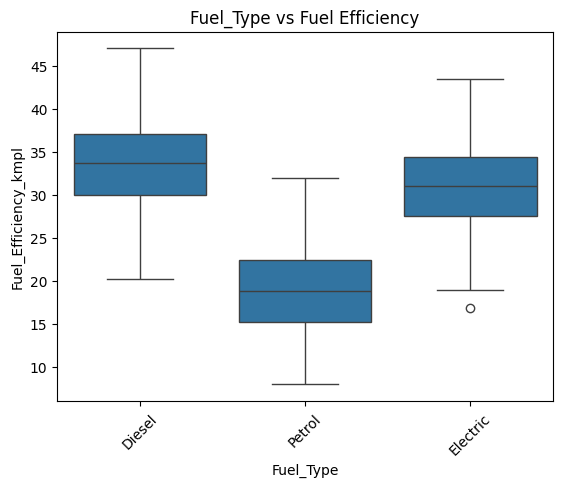

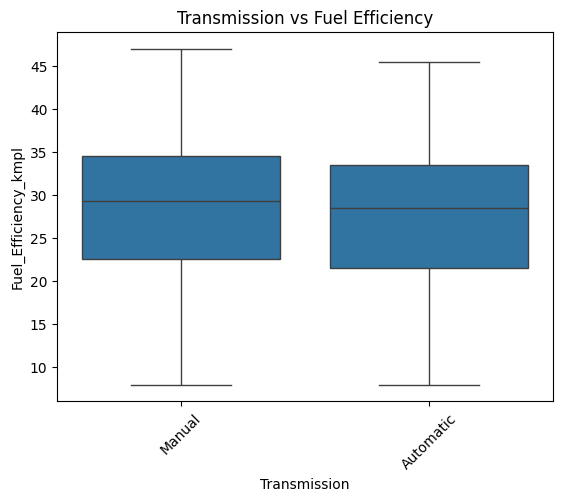

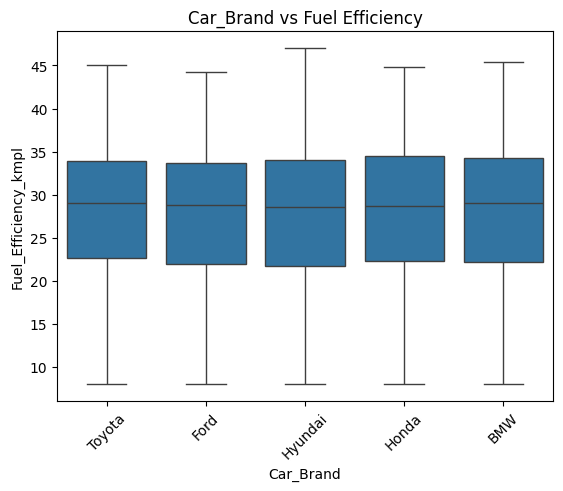

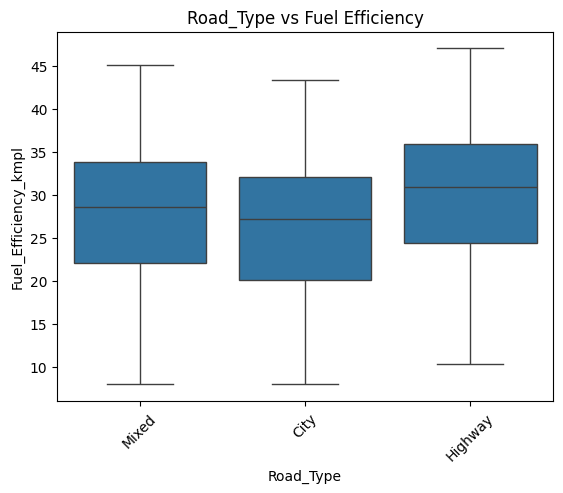

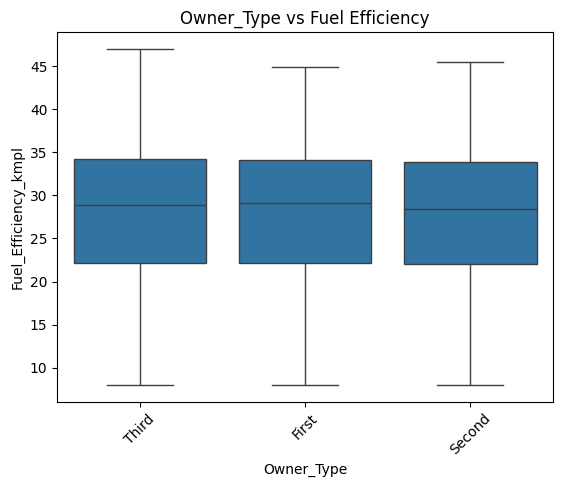

In [137]:
# categorical vs Target
for col in cat_cols:
    plt.figure()
    sns.boxplot(x=df[col], y=df["Fuel_Efficiency_kmpl"])
    plt.title(f"{col} vs Fuel Efficiency")
    plt.xticks(rotation=45)
    plt.show()

##### Observation:- 1. Fuel_Type vs Fuel Efficiency
1. Efficiency differs by fuel type.
2. Fuel type strongly affects target.

##### Observation:- 2.Transmission vs Fuel Efficiency
1. Manual and Automatic show different medians.
2. Transmission influences efficiency.

##### Observation:- 3.Car_Brand vs Fuel Efficiency
1. Some brands perform better than others.
2. Brand-level engineering matters.

##### Observation:- 4.Road_Type vs Fuel Efficiency
1. Highway / City values differ.
2. Road condition impacts mileage.

##### Observation:- 5.Owner_Type vs Fuel Efficiency
1. First-owner vehicles may differ from third-owner.
2. Ownership can reflect wear/maintenance.

## feature engineering

In [138]:
# Separate Features & Target
X = df.drop("Fuel_Efficiency_kmpl",axis=1) # Target variable is F
y = df["Fuel_Efficiency_kmpl"]

##### Observation:
1. X contains all input features like engine size, horsepower, weight, mileage, fuel type, etc.
2. y contains the target variable Fuel_Efficiency_kmpl, which we want to predict.
3. Since the target has continuous numeric values, this is a Regression problem.

In [139]:
# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### Observation:
1. The dataset is divided into training data (80%) and testing data (20%) to build and evaluate the model.
2. random_state=42 ensures the split is consistent and reproducible every time the code runs.

# Data Preprocessing

In [140]:
# Define Column Types
num_cols = [
    "Engine_Size_L",
    "Horsepower",
    "Weight_kg",
    "Mileage_km_per_year",
    "Fuel_Tank_Capacity",
    "Age_of_Car",
    "Service_Visits_Per_Year"
]

In [141]:
onehot_cols = [
    "Fuel_Type",
    "Transmission",
    "Car_Brand",
    "Road_Type"
]


In [142]:
ordinal_cols = ["Owner_Type"]
ordinal_cols


['Owner_Type']

In [143]:
# Numerical Pipline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [144]:
# OneHot Encoding Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [145]:
# Ordinal Encoding Pipeline
ord_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["First", "Second", "Third"]]
    ))
])


##### Observation:-
1. Separate preprocessing pipelines were created for numerical, categorical, and ordinal columns based on their data types.
2. Missing values were handled using SimpleImputer, numerical data was scaled, categorical data was one-hot encoded, and ordered categories were ordinal encoded.
3. This organized preprocessing ensures each feature type is transformed correctly before model training.

In [146]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, onehot_cols),
    ("ord", ord_pipeline, ordinal_cols)
])

In [147]:
# Fit on train data
X_train_processed = preprocessor.fit_transform(X_train)

In [148]:
# Transform test data
X_test_processed = preprocessor.transform(X_test)


In [149]:
# Final shapes
print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 21)
X_test shape: (1000, 21)
y_train shape: (4000,)
y_test shape: (1000,)


##### Observation:-
1. The final shapes of X_train_processed and X_test_processed show the transformed feature datasets after preprocessing.
2. The number of rows remains the same, while the number of columns increases due to encoding of categorical variables.
3. This confirms that the training and testing data are successfully processed and ready for model training.

In [150]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [151]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [152]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### Observation:
1. The scaler is trained using only the training data and then applied to test data.
2. This avoids data leakage and keeps the model fair.
3. All features are brought to the same scale, which helps models like KNN perform better.

## model building

In [153]:
# LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [154]:
y_pred = model.predict(X_test)

In [155]:
print("r2 score:",r2_score(y_test,y_pred))

r2 score: 0.9999879272466282


##### Observation:
1. Linear Regression was used as a baseline model to predict Fuel_Efficiency_kmpl using the training data.
2. The model predictions were generated on the test data and evaluated using the R² score.
3. The high R² score indicates that the model explains most of the variation in fuel efficiency for this dataset.

In [156]:
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [157]:
y_pred_rf = rf.predict(X_test)

In [158]:
print("Random Forest Results:")
print("R2:",r2_score(y_test,y_pred_rf))
print("MAE:", mean_absolute_error(y_test,y_pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_rf)))

Random Forest Results:
R2: 0.9824132978499199
MAE: 0.8490642999999991
RMSE: 1.0646592620317534


##### Observation:
1. Random Forest model was trained on the training data to predict Fuel_Efficiency_kmpl using multiple decision trees.
2. The model achieved a very high R² score with low MAE and RMSE, showing strong prediction performance.
3. This indicates Random Forest captured the relationships between features and fuel efficiency effectively.

In [159]:
# KNN
Knn = KNeighborsRegressor(n_neighbors=5)
Knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [160]:
y_pred_knn = Knn.predict(X_test)

In [161]:
print("KNN Results:")
print("R2:",r2_score(y_test,y_pred_knn))
print("MAE:",mean_absolute_error(y_test,y_pred_knn))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_knn)))

KNN Results:
R2: 0.8624053560406306
MAE: 2.3735739999999996
RMSE: 2.9779623093652474


In [162]:
# Ridge Regression
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_processed, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [163]:
y_pred_ridge = ridge.predict(X_test_processed)

In [164]:
print("Ridge Regression Results:")
print("R2",r2_score(y_test,y_pred_ridge))
print("MAE:",mean_absolute_error(y_test,y_pred_ridge))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_ridge)))  # the best model is ridge regression

Ridge Regression Results:
R2 0.9999879176133545
MAE: 0.013329727855565495
RMSE: 0.027905820546120272


In [165]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_processed, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [166]:
y_pred_lasso = lasso.predict(X_test_processed)

In [167]:
print("Lasso results")
print("R2:",r2_score(y_test,y_pred_lasso))
print("MAE:",mean_absolute_error(y_test,y_pred_lasso))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso results
R2: 0.9968004216684125
MAE: 0.36707546031103455
RMSE: 0.45411391091263487


In [168]:
# XGBoost Regressor
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [169]:
y_pred_xgb =xgb.predict(X_test_processed)

In [170]:
print("XGBoost Results")
print("R2:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost Results
R2: 0.9947676518651852
MAE: 0.4648025691223145
RMSE: 0.5807199532812004


# Hyperparameter Tuning

In [171]:
# Hyperparameter Tuning
param_grid = {
    "n_estimators": [100],
    "max_depth": [10,  None]
}

In [172]:
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [173]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

In [174]:
print("Best Parameter:", grid.best_params_)

Best Parameter: {'max_depth': None, 'n_estimators': 100}


In [175]:
best_model = grid.best_estimator_

In [176]:
y_pred = best_model.predict(X_test)

In [177]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.9824132978499199
MAE: 0.8490642999999991
RMSE: 1.0646592620317534


In [178]:
# save model in colab
import joblib
joblib.dump(ridge, "fuel_efficiency_model.pkl")

['fuel_efficiency_model.pkl']